In [1]:
#!pip install pyedflib #lasciare commentato grazie(impiega 20 anni per compilare)

In [2]:
import pyedflib
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tempfile
import h5py
import gc
import os
from scipy import signal
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

# --- CONFIGURAZIONE S3 ---
BUCKET = "btw-ml-data"
BASE_PATH = "polito-thesis/"
ECG_PATH = BASE_PATH + "record%s.edf"

# --- PARAMETRI TECNICI ---
FS_OLD, FS_NEW = 1000, 125
WIN_SIZE, STRIDE = 250, 125  # Finestre di 2s (250 campioni), slide di 1s
EXPECTED_LENGTH = 3750       # 30 secondi a 125Hz

# --- ORDINAMENTO LEAD (Standard Internazionale) ---
LIMB_LEADS = ['I', 'II', 'III', 'aVr', 'aVl', 'aVf']
PRECORDIAL_LEADS = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6']
ALL_LEADS = LIMB_LEADS + PRECORDIAL_LEADS

# --- MAPPING 1: PULIZIA ETICHETTE REALI (Dal Medico alla Tesi) ---
# Questo risolve il caos di sigle come RF, LF, RN, orario...
LABEL_MAP_CLEAN = {
    'normale': 'normale',
    'RL': 'RL-RA',             # La classe RL generica viene mappata al Mode 6
    'antiorario': 'ROT_ANTIORARIA',
    'orario': 'ROT_ORARIA',
    'RF': 'RA-LL',             # Rosso-Verde (Mode 2)
    'LF': 'LA-LL',             # Giallo-Verde (Mode 3)
    'RN': 'RL-RA',             # Rosso-Nero (Mode 6)
    'LN': 'RL-LA'              # Giallo-Nero (Mode 7)
}

# --- MAPPING 2: SIMULAZIONE (Data Augmentation) ---
# Questi sono i mode che la funzione limb_interchange_simulation deve saper gestire
MAPPING_INV = {
    'LA-RA': 1, 
    'RA-LL': 2, 
    'LA-LL': 3, 
    'ROT_ORARIA': 4, 
    'ROT_ANTIORARIA': 5,
    'RL-RA': 6, 
    'RL-LA': 7
}

print("Configurazione completata. Pronto per il caricamento dei dati.")

Configurazione completata. Pronto per il caricamento dei dati.


In [3]:
# Configurazione S3

def read_s3_object(bucket_name, object_key, write_to=None, raise_errors=False):
    try:
        s3_client = boto3.client('s3')
        response = s3_client.get_object(Bucket=bucket_name, Key=object_key)
        content = response['Body'].read()
        if write_to is not None:
            with open(write_to, 'wb') as f:
                f.write(content)
        return content
    except Exception as e:
        if raise_errors:
            raise e
        else:
            print(f"Error reading S3 object: {e}")
            return None


def write_s3_object(bucket_name, object_key, file_name):
    try:
        s3_client = boto3.client('s3')
        s3_client.upload_file(file_name, bucket_name, object_key)
    except Exception as e:
        print(f"Error writing S3 object: {e}")
        return False
    return True


# leggiamo, puliamo e ordiniamo il dato
def read_edf_data(bytes_data):
    """
    Converte i bytes di un file EDF in:
    {
      "signals": {lead_name: np.array(...), ...},
      "duration_sec": float
    }
    con pulizia/mappatura robusta delle etichette
    e riordino finale secondo ALL_LEADS.
    """
    with tempfile.NamedTemporaryFile(delete=True) as tmp_file:
        tmp_file.write(bytes_data)
        tmp_file.seek(0)
        f = pyedflib.EdfReader(tmp_file.name)
        try:
            n_sig = f.signals_in_file

            mapping = {
                'AVR': 'aVr',
                'AVL': 'aVl',
                'AVF': 'aVf',
                'DI': 'I',
                'DII': 'II',
                'DIII': 'III'
            }

            labels_clean = []
            for raw in f.getSignalLabels():
                raw_up = raw.strip().upper()
                clean = (
                    raw_up
                    .replace("ECG", "")
                    .replace("LEAD", "")
                    .replace("-", "")
                    .strip()
                )
                final_label = mapping.get(clean, clean)
                labels_clean.append(final_label)

            sigs = [f.readSignal(i) for i in range(n_sig)]
            duration = f.getFileDuration()
        finally:
            f.close()

        signals_raw = {
            labels_clean[i]: sigs[i]
            for i in range(len(labels_clean))
        }

        signals_ordered = {
            lead: signals_raw[lead]
            for lead in ALL_LEADS
            if lead in signals_raw
        }

        return {
            "signals": signals_ordered,
            "duration_sec": duration
        }
# funzione di alto livello che legge dal bucket S3 e ritorna un ECG convertito
def get_ecg(ecgId):
    data = read_s3_object(BUCKET, ECG_PATH % ecgId)
    if data:
        return read_edf_data(data)
    return None

In [4]:
# get a sample ordinato
ecg = get_ecg(674515)
print(ecg)

{'signals': {'I': array([-88.12548257, -87.55326925, -85.64589151, ...,  76.67195392,
        77.62564279,  78.77006943]), 'II': array([355.91205463, 350.57139696, 349.04549477, ..., 189.77945373,
       198.36265354, 206.56437781]), 'III': array([444.03290608, 438.1200351 , 434.68675517, ..., 113.1028687 ,
       120.73237964, 127.78967727]), 'aVr': array([-133.90254826, -131.4229572 , -131.61369497, ..., -133.13959716,
       -137.9080415 , -142.67648585]), 'aVl': array([-266.08382544, -262.84128328, -260.17095445, ...,  -18.12471962,
        -21.55799954,  -24.41906615]), 'aVf': array([399.97248035, 394.25034714, 391.77075608, ..., 151.44116121,
       159.64288548, 167.27239643]), 'V1': array([236.31947051, 236.70094606, 236.51020829, ..., 136.75435264,
       128.74336614, 124.73787289]), 'V2': array([39.0966125 , 36.04480812, 31.27636378, ..., 50.92235447,
       42.33915465, 35.4725948 ]), 'V3': array([-116.35467308, -117.88057527, -117.88057527, ...,  -23.08390173,
        -24.

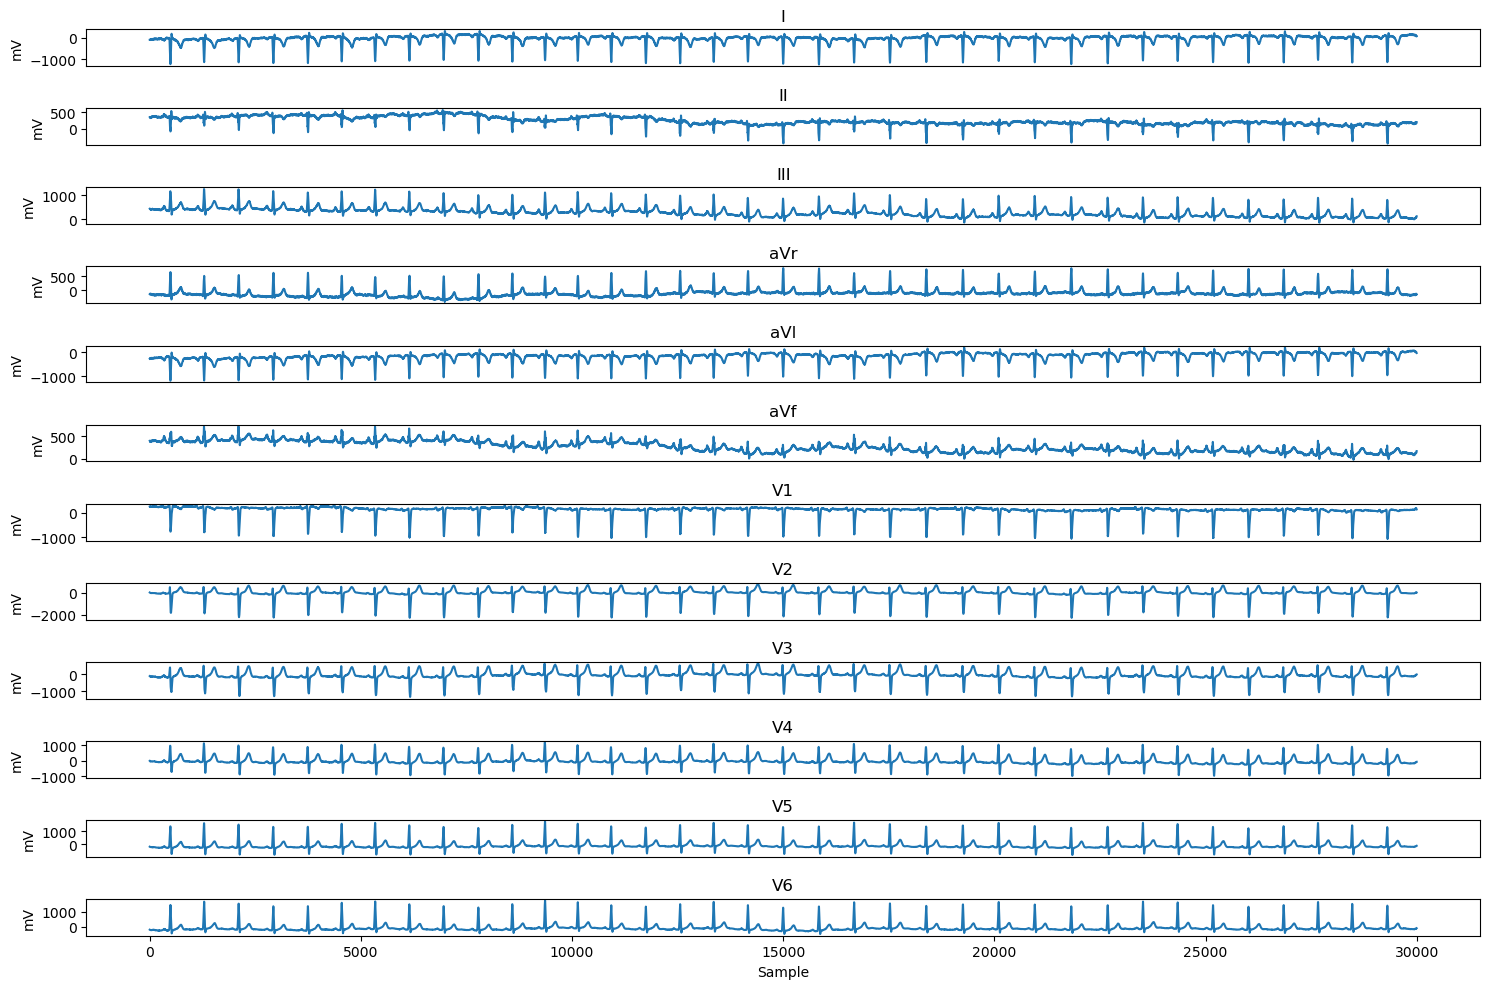

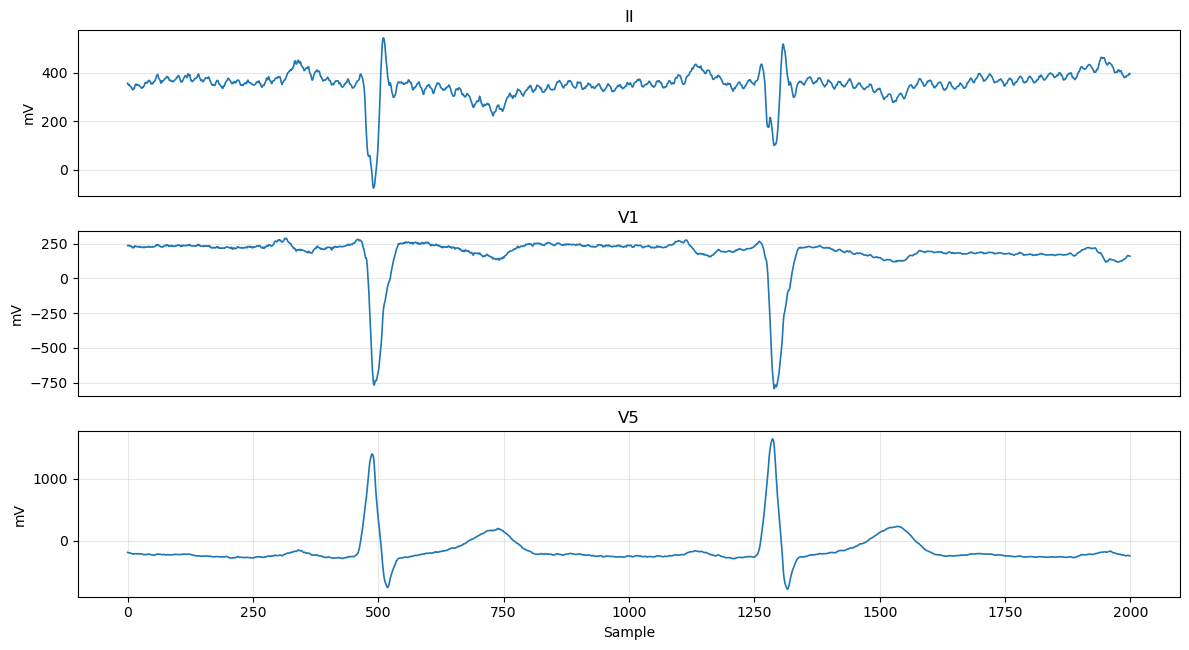

In [5]:
# plot a sample
def plot_a_sample(signal):
    plt.figure(figsize=(15, 10))
    
    for i, lead in enumerate(ALL_LEADS, start=1):
        plt.subplot(len(ALL_LEADS), 1, i)
        plt.plot(signal[lead])
        plt.title(lead)
        plt.ylabel('mV')
        if i < len(ALL_LEADS):
            plt.xticks([])  # niente x-label per le derivate intermedie
    
    plt.xlabel('Sample')
    plt.tight_layout()
    plt.show()

# per vedere meglio, con n_samples e numero di leads configurabile, anche da dove parte
def plot_a_beat(signal, n_samples=250, leads=None, start=0):
    if leads is None:
        leads = list(signal.keys())   # tutte le derivazioni
    
    plt.figure(figsize=(12, 2.2 * len(leads)))
    
    for i, lead in enumerate(leads, start=1):
        plt.subplot(len(leads), 1, i)
        segment = signal[lead][start:start+n_samples]
        plt.plot(segment, linewidth=1.2)
        plt.title(lead)
        plt.ylabel("mV")
        plt.grid(True, alpha=0.3)
        
        if i < len(leads):
            plt.xticks([])
    
    plt.xlabel("Sample")
    plt.tight_layout()
    plt.show()

plot_a_sample(ecg["signals"])
plot_a_beat(ecg["signals"], n_samples=250*8, leads=["II", "V1", "V5"])

In [6]:
# DATAFRAME

In [7]:
# stampiamo il dataframe per vederne le etichette
df = pd.read_csv("s3://" + BUCKET + "/" + BASE_PATH + "thesis-sample.csv")
print(df)

# stampiamo la durata dei primi 10 elementi
count = 0
for n in df['Num']:
    ecg = get_ecg(n)
    print(ecg['duration_sec'])
    count += 1
    if count == 10:
        break
# nota: non tutti i campioni hanno la durata di 30s

# osserviamo quante occorrenze ci sono della stessa classe
print(df.value_counts("Inversione"))

         Num  Inversione                                            Referto
0    1183538          RL                               elettrodi invertiti.
1    1181980          RL  elettrodi invertiti nelle derivazioni periferi...
2    1180063          RL                             derivazioni invertite.
3    1180034          RL                  derivazioni periferiche invertite
4    1178920          RL              posizionamento elettrodi arti errato.
..       ...         ...                                                ...
477   677835          RL  ecg da ripetere. probabile mal posizionamento ...
478   674515  antiorario   errata posizione elettrodi degli arti. ripetere.
479   669511          RL                              inversione elettrodi.
480   669145      orario                              tracciato da ripetere
481   669089          RL                             Inversione periferiche

[482 rows x 3 columns]
30.0
30.0
30.0
30.0
30.0
19.0
30.0
30.0
30.0
30.0
Inversione
nor

In [8]:
# prendiamo solo i casi interessanti
def get_df_valido(df, get_ecg_func, min_duration_sec=30.0):
    """
    - rimuove i casi con Inversione == "?"
    - rimappa le etichette secondo LABEL_MAP_CLEAN
    - tiene solo i record con durata == min_duration_sec
    - scarta gli ECG che non hanno tutte le 12 derivazioni
    - NON salva più l'ECG completo
    """
    # 1) Rimuovi i casi dubbi
    df_valido = df[df["Inversione"] != "?"].copy()

    # 1bis) Rimappa le label standard
    df_valido["Inversione"] = df_valido["Inversione"].apply(
        lambda x: LABEL_MAP_CLEAN.get(x, x)
    )

    # 2) Recupera ecg completi (solo per durata e num_leads)
    ecg_list = df_valido["Num"].apply(get_ecg_func)

    # 3) Aggiungi la durata
    df_valido["durata"] = ecg_list.apply(lambda ecg: ecg["duration_sec"])
    # 4) Filtra per durata esatta
    df_valido = df_valido[df_valido["durata"] == float(min_duration_sec)].copy()
    ecg_list = ecg_list.loc[df_valido.index]

    # 5) Scarta ECG che non hanno esattamente len(ALL_LEADS) derivazioni
    mask_ok = ecg_list.apply(lambda ecg: len(ecg["signals"]) == len(ALL_LEADS))
    df_valido = df_valido[mask_ok].copy()

    # niente colonna 'ecg', il df contiene solo Num, Inversione, durata, ecc.
    return df_valido

df_valido = get_df_valido(df, get_ecg_func=get_ecg)
print(f"\n✅ Dataset finale: {len(df_valido)} ECG con durata di 30s e 12 derivazioni")
print(df_valido.value_counts("Inversione"))


✅ Dataset finale: 437 ECG con durata di 30s e 12 derivazioni
Inversione
normale           191
RL-RA             181
ROT_ANTIORARIA     27
LA-LL              14
RA-LL              14
ROT_ORARIA          7
RL-LA               1
Name: count, dtype: int64


In [9]:
#PIPELINE PREPROCESSING + AUGMENTATION

In [10]:
# funzioni utils

# preprocessing di un singolo segnale
def leads_preprocessing(raw_signal):
    x = np.asarray(raw_signal, dtype=np.float64).squeeze()

    if x.ndim != 1:
        raise ValueError("raw_signal deve essere 1D")

    if x.size == 0:
        return np.array([], dtype=np.float32)

    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    # 1) Bandpass per ML ECG: rimuove baseline wander e rumore HF
    sos = signal.butter(
        N=4,
        Wn=[0.05, 40.0],
        btype="bandpass",
        fs=FS_OLD,
        output="sos"
    )
    x = signal.sosfiltfilt(sos, x)

    # 2) Downsampling con anti-aliasing, fattore 8
    x = signal.resample_poly(x, up=1, down=FS_OLD//FS_NEW)

    # 3) Z-score finale
    mean = np.mean(x)
    std = np.std(x)
    if not np.isfinite(std) or std < 1e-8:
        return np.zeros_like(x, dtype=np.float32)

    x = (x - mean) / std
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    return x.astype(np.float32)
    
# preprocessing su tutte le derivazioni
def all_leads_preprocessing(signals_dict):
    processed = {}
    for lead_name, sig in signals_dict.items():
        processed[lead_name] = leads_preprocessing(sig)
    return processed
    

# da applicare solo con etichetta normale
def limb_interchange_simulation(mode, signals_dict):
    # prendiamo solo le periferiche preservando l'ordine predefinito
    leads = np.array([signals_dict[l] for l in LIMB_LEADS])
    # array copia dove mettere le trasformazioni
    transformed = np.copy(leads)

    # --- 1. SCAMBI SEMPLICI TRA ARTI ---
    if mode == 1: # LA-RA
        transformed[0], transformed[1], transformed[2] = -leads[0], leads[2], leads[1]
        transformed[3], transformed[4] = leads[4], leads[3]
    elif mode == 2: # RA-LL
        transformed[0], transformed[1], transformed[2] = -leads[2], -leads[1], -leads[0]
        transformed[3], transformed[5] = leads[5], leads[3]
    elif mode == 3: # LA-LL
        transformed[0], transformed[1], transformed[2] = leads[1], leads[0], -leads[2]
        transformed[4], transformed[5] = leads[5], leads[4]

    # --- 2. ROTAZIONI 
    elif mode == 4: # RA -> LA -> LL -> RA (Rotazione Oraria)
        transformed[0], transformed[1], transformed[2] = leads[2], -leads[0], -leads[1]
        transformed[3], transformed[4], transformed[5] = leads[4], leads[5], leads[3]
    elif mode == 5: # RA -> LL -> LA -> RA (Rotazione Antioraria)
        transformed[0], transformed[1], transformed[2] = -leads[1], -leads[2], leads[0]
        transformed[3], transformed[4], transformed[5] = leads[5], leads[3], leads[4]

    # --- 3. SCAMBI CON RL ---
    elif mode == 6:  # RL-RA (elettrodo RA messo a RL, RA "scompare" dai calcoli)
        # I = LA - RA ≈ LA - 0 = LA
        # II = LL - RA ≈ LL - 0 = LL
        # III = LL - LA (rimane uguale)
        transformed[0], transformed[1], transformed[2] = leads[1], leads[2], leads[2] - leads[1]
        # aVr = - (I + II)/2
        transformed[3] = -0.5 * (transformed[0] + transformed[1])
        # aVl = I - II/2
        transformed[4] = transformed[0] - 0.5 * transformed[1]
        # aVf = II - I/2
        transformed[5] = transformed[1] - 0.5 * transformed[0]

    elif mode == 7:  # RL-LA (elettrodo LA messo a RL, LA "scompare" dai calcoli)
        # I = LA - RA ≈ 0 - RA = -RA = -II + LL
        # II = LL - RA (rimane uguale)
        # Usiamo Einthoven: III = II - I
        transformed[1] = leads[1]            # II invariata
        transformed[0] = leads[2] - leads[1] # I ≈ -RA ricostruita come LL - II
        transformed[2] = transformed[1] - transformed[0]  # III = II - I
        # aVr, aVl, aVf dai soliti mix di Einthoven
        transformed[3] = -0.5 * (transformed[0] + transformed[1])   # aVr
        transformed[4] = transformed[0] - 0.5 * transformed[1]      # aVl
        transformed[5] = transformed[1] - 0.5 * transformed[0]      # aVf
    
    # mettiamo i segnali trasformati in ordine    
    new_sigs = {name: transformed[i] for i, name in enumerate(LIMB_LEADS)}
    # e le precoridali as-it-is
    for l in signals_dict:
        if l not in LIMB_LEADS: new_sigs[l] = signals_dict[l]
    return new_sigs

# abbiamo [(l-w)/stride]+1
def create_windows(signals_dict):
    full_signal = np.array([signals_dict[l] for l in ALL_LEADS])
    windows = []
    for start in range(0, full_signal.shape[1] - WIN_SIZE + 1, STRIDE):
        windows.append(full_signal[:, start : start + WIN_SIZE])
    return np.array(windows, dtype='float32')

{'I': array([-0.18140838, -0.26922643, -0.21923123, ..., -0.26724768,
       -0.27289465, -0.19979753], dtype=float32), 'II': array([-0.00240927,  0.03105225,  0.10875596, ...,  0.21799964,
        0.19340345,  0.1708853 ], dtype=float32), 'III': array([0.11469807, 0.19631246, 0.2227475 , ..., 0.3358962 , 0.32099122,
       0.25707686], dtype=float32), 'aVr': array([ 0.12077983,  0.15225756,  0.05986469, ...,  0.00677384,
        0.0292973 , -0.00137326], dtype=float32), 'aVl': array([-0.15392293, -0.24555136, -0.2418511 , ..., -0.33841562,
       -0.33083943, -0.2569544 ], dtype=float32), 'aVf': array([0.06836798, 0.13322519, 0.18474375, ..., 0.30261365, 0.28235504,
       0.233376  ], dtype=float32), 'V1': array([ 0.02911387,  0.12034422,  0.05662797, ..., -0.40424892,
       -0.23946176, -0.12671998], dtype=float32), 'V2': array([ 0.25164923,  0.37809598,  0.2382393 , ..., -0.30674914,
       -0.17254093, -0.13062043], dtype=float32), 'V3': array([ 0.22273865,  0.36768284,  0.318955

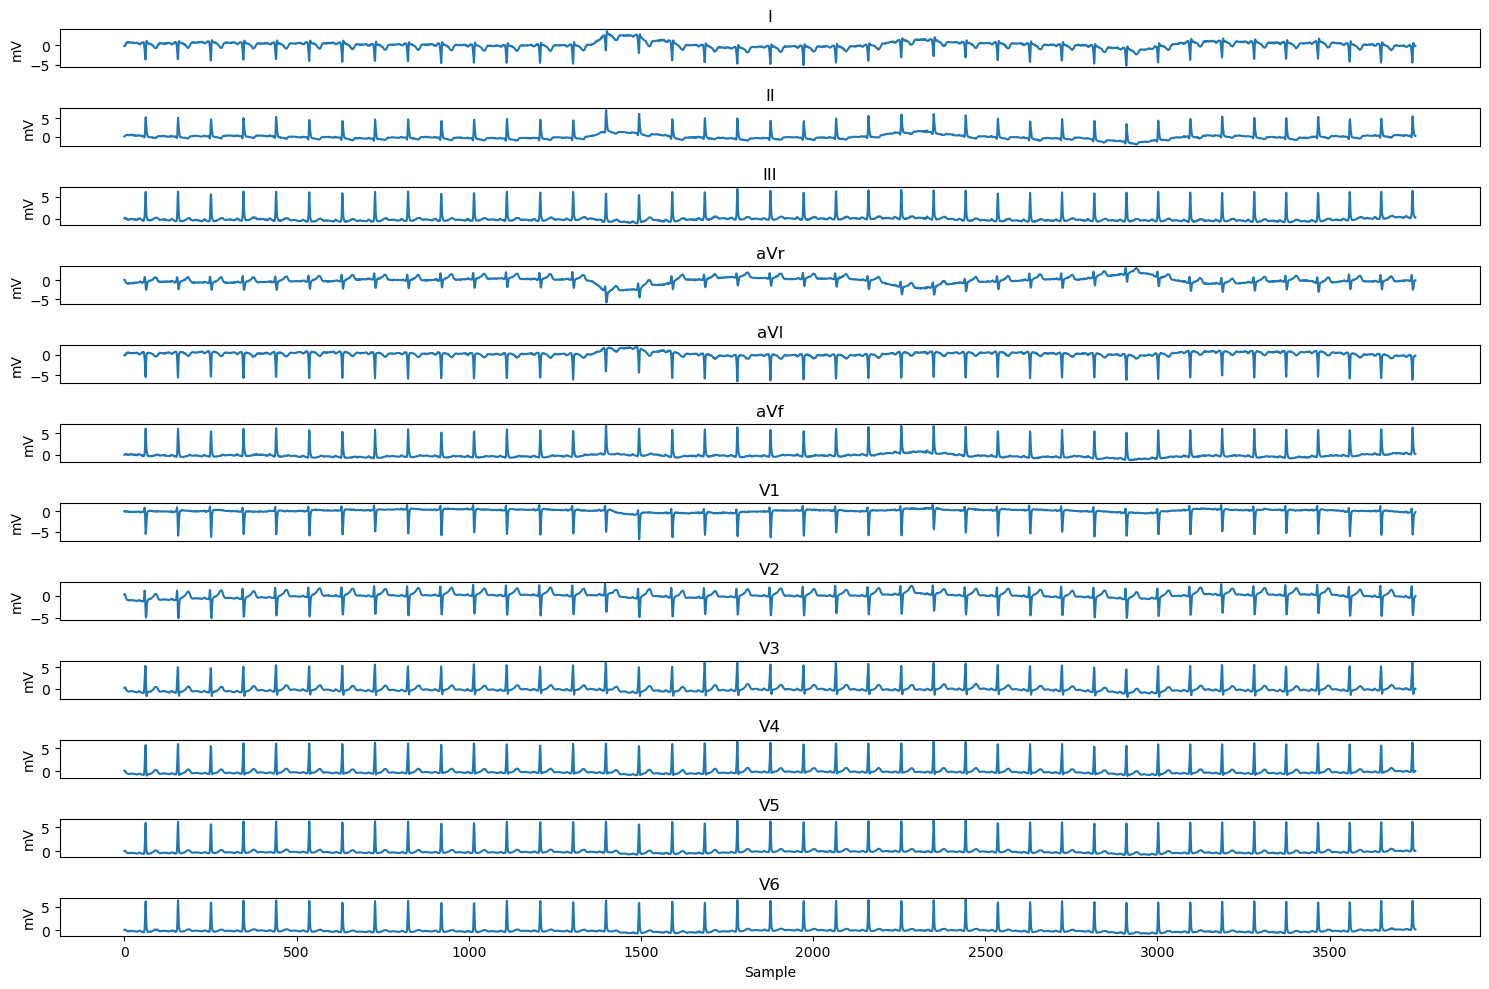

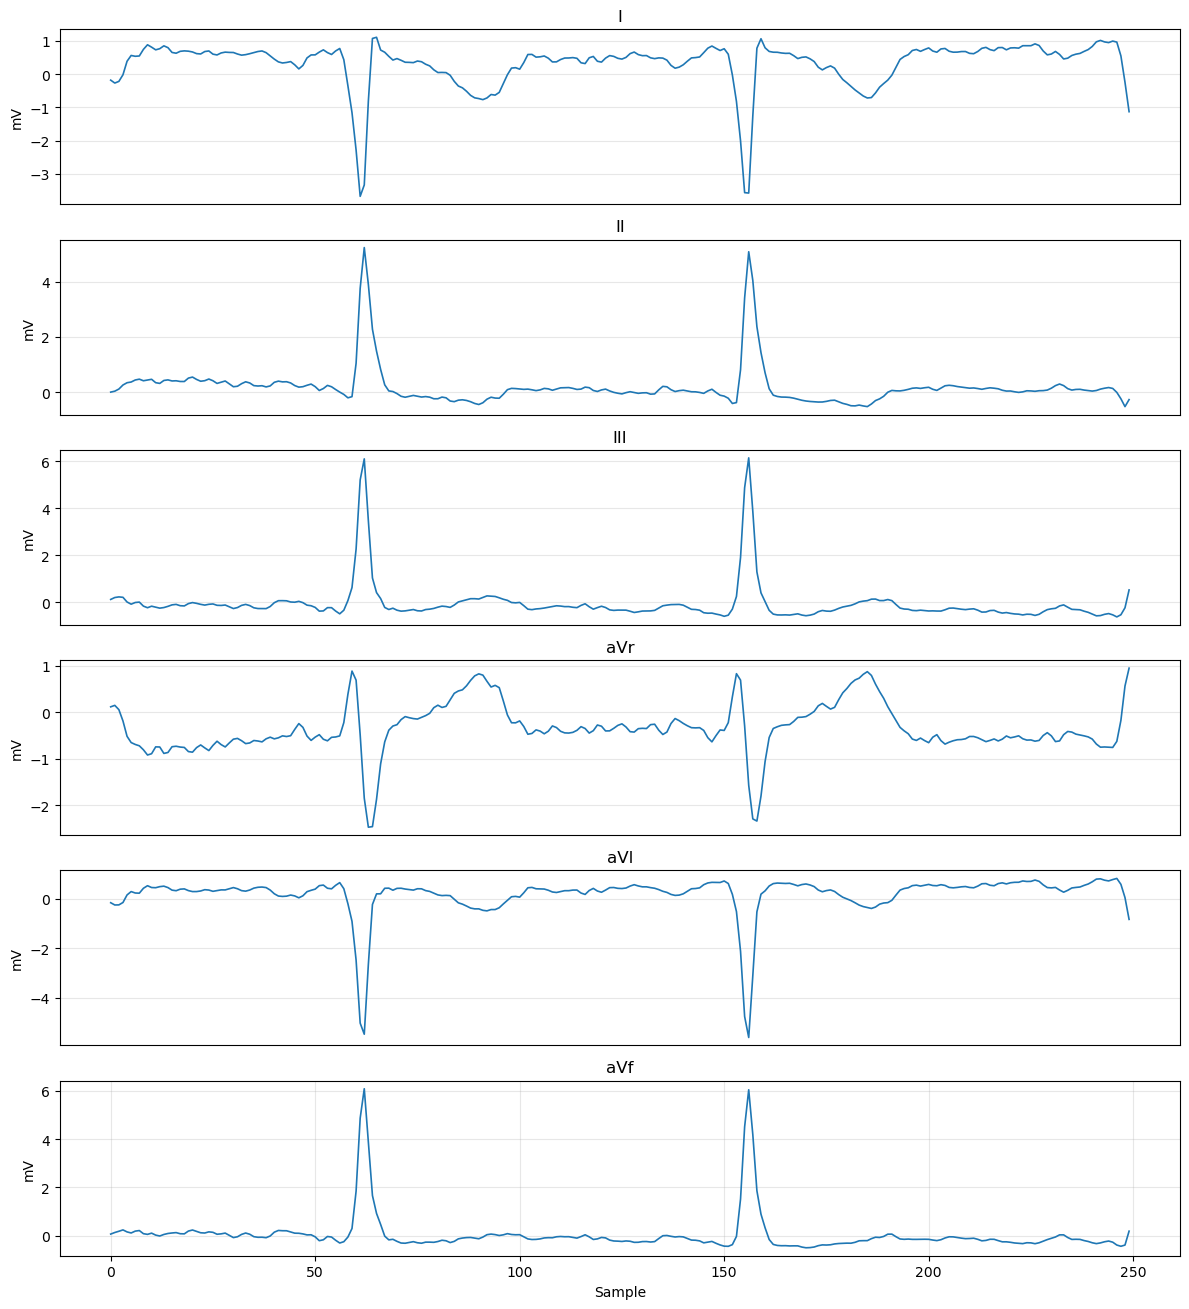

In [11]:
# testiamo preprocessing
ecg_preprocessed = all_leads_preprocessing(ecg["signals"])
print(ecg_preprocessed)
plot_a_sample(ecg_preprocessed) # dovremmo avere 125*30 campioni

plot_a_beat(ecg_preprocessed, n_samples=250, leads=LIMB_LEADS)


1


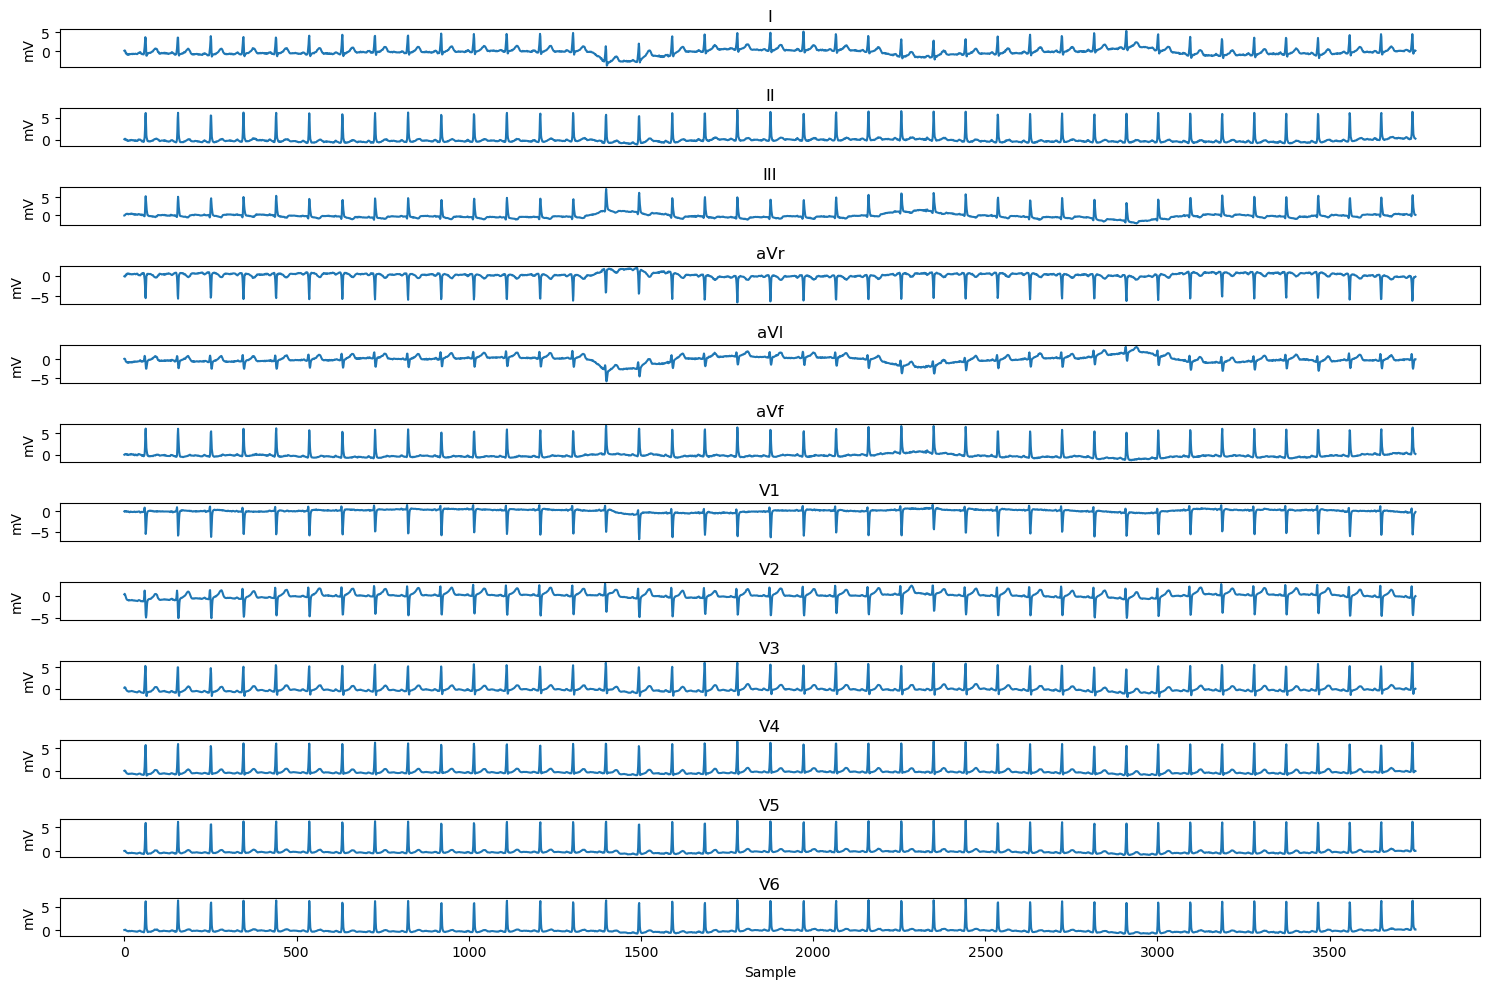

In [12]:
# testiamo la data augmentation con LA-RA (la prima derivazione invertita, II e III che si scambiano come aVR e aVL)
print(MAPPING_INV["LA-RA"])
ecg_augmented= limb_interchange_simulation( MAPPING_INV["LA-RA"],ecg_preprocessed)
plot_a_sample(ecg_augmented)

In [13]:
# DATASET CREATION

In [14]:
# usiamo df_valido come dataframe

# prendiamo tutti gli id, da dividere
tutti_gli_id = df_valido['Num'].unique()

# Split 1: Separiamo il Test (15%)
train_val_ids, test_ids = train_test_split(tutti_gli_id, test_size=0.15, random_state=42)

# Split 2: Dividiamo il resto tra Train e Validation
train_ids, val_ids = train_test_split(train_val_ids, test_size=0.18, random_state=42)

print(f"✅ ID pronti: Train={len(train_ids)}, Val={len(val_ids)}, Test={len(test_ids)}")

✅ ID pronti: Train=304, Val=67, Test=66


In [15]:
import gc
import os
import h5py
import numpy as np
from tqdm import tqdm


def build_h5_dataset(ids_list, h5_name, augment=False):
    if os.path.exists(h5_name):
        os.remove(h5_name)

    h5_tmp = h5_name + ".tmp"
    if os.path.exists(h5_tmp):
        os.remove(h5_tmp)

    label_to_int = {lab: idx for idx, lab in enumerate(['normale'] + list(MAPPING_INV.keys()))}

    all_labels = list(MAPPING_INV.keys()) + ['normale']

    class_real_counts = {}
    for label in all_labels:
        n_ids = len(
            df_valido[
                (df_valido['Num'].isin(ids_list)) &
                (df_valido['Inversione'] == label)
            ]
        )
        class_real_counts[label] = n_ids * 29

    target_windows = class_real_counts.get('normale', 0)
    if target_windows == 0:
        raise ValueError("Nessun ECG 'normale' nel split.")

    class_counters = {k: 0 for k in all_labels}

    # Quante finestre servono ancora per ciascuna classe sintetica
    # Se una classe ha già abbastanza reali, il valore è 0
    needed_per_class = {
        lab: max(0, target_windows - class_real_counts.get(lab, 0))
        for lab in MAPPING_INV.keys()
    }

    print(f"\n🚀 Scrittura dati in {h5_tmp}")
    print(f"🎯 Target finestre per classe sotto-soglia: {target_windows}")

    with h5py.File(h5_tmp, 'w') as f:
        dset_x = f.create_dataset(
            'X',
            shape=(0, 12, 250),
            maxshape=(None, 12, 250),
            dtype='float32',
            chunks=(64, 12, 250),
            compression='lzf'
        )
        dset_y = f.create_dataset(
            'Y',
            shape=(0,),
            maxshape=(None,),
            dtype='int8'
        )

        for ecg_id in tqdm(ids_list, desc="Raccolta finestre"):
            try:
                ecg_data = get_ecg(ecg_id)
                if ecg_data is None:
                    continue

                raw_data = ecg_data["signals"]
                if not raw_data:
                    continue

                row = df_valido[df_valido['Num'] == ecg_id]
                if row.empty:
                    continue

                label_reale = str(row['Inversione'].values[0])
                if label_reale not in label_to_int:
                    print(f"  ⚠️ Label sconosciuta '{label_reale}' per ID {ecg_id}, skip.")
                    continue

                sigs = all_leads_preprocessing(raw_data)

                # --- Caso reale: sempre tenuto tutto ---
                wins_r = create_windows(sigs)
                if wins_r.shape[0] == 0:
                    continue

                labels_r = np.full(
                    wins_r.shape[0],
                    label_to_int[label_reale],
                    dtype='int8'
                )
                _append_to_h5(dset_x, dset_y, wins_r, labels_r)
                class_counters[label_reale] += wins_r.shape[0]

                # --- Augmentation solo da ECG normali, solo nel train ---
                if augment and label_reale == 'normale':
                    # Se tutte le classi sono già saturate, evita lavoro inutile
                    if any(v > 0 for v in needed_per_class.values()):
                        for inv_name, mode in MAPPING_INV.items():
                            needed = needed_per_class[inv_name]

                            # Classe già satura o già sopra target coi reali
                            if needed <= 0:
                                continue

                            try:
                                sim_sigs = limb_interchange_simulation(mode, sigs)
                                wins_s = create_windows(sim_sigs)

                                if wins_s.shape[0] == 0:
                                    del sim_sigs
                                    continue

                                # Aggiungi solo il numero strettamente necessario
                                n_add = min(needed, wins_s.shape[0])
                                if n_add <= 0:
                                    del sim_sigs, wins_s
                                    continue

                                wins_to_add = wins_s[:n_add]
                                labels_s = np.full(
                                    n_add,
                                    label_to_int[inv_name],
                                    dtype='int8'
                                )

                                _append_to_h5(dset_x, dset_y, wins_to_add, labels_s)

                                class_counters[inv_name] += n_add
                                needed_per_class[inv_name] -= n_add

                                del sim_sigs, wins_s, wins_to_add, labels_s

                            except Exception as e_aug:
                                print(f"  ⚠️ Augmentation fallita ID {ecg_id}, mode {inv_name}: {e_aug}")

                del raw_data, sigs, wins_r, labels_r
                gc.collect()

            except Exception as e:
                print(f"  ❌ Errore ID {ecg_id}: {e}")
                continue

        total = dset_x.shape[0]

    print(f"\n🔀 Shuffle di {total} finestre → {h5_name}")

    rng = np.random.default_rng(seed=42)
    shuffled_idx = rng.permutation(total)

    BLOCK = 4096

    with h5py.File(h5_tmp, 'r') as src, h5py.File(h5_name, 'w') as dst:
        dst_x = dst.create_dataset(
            'X',
            shape=(total, 12, 250),
            dtype='float32',
            chunks=(64, 12, 250),
            compression='lzf'
        )
        dst_y = dst.create_dataset(
            'Y',
            shape=(total,),
            dtype='int8'
        )
        dst.attrs['label_map'] = str(label_to_int)

        for start in tqdm(range(0, total, BLOCK), desc="Scrittura shuffled"):
            end = min(start + BLOCK, total)
            block_idx = shuffled_idx[start:end]

            sorted_pos = np.argsort(block_idx)
            sorted_idx = block_idx[sorted_pos]

            x_block = src['X'][sorted_idx]
            y_block = src['Y'][sorted_idx]

            inv_sort = np.argsort(sorted_pos)
            dst_x[start:end] = x_block[inv_sort]
            dst_y[start:end] = y_block[inv_sort]

            del x_block, y_block
            gc.collect()

    os.remove(h5_tmp)
    print(f"✅ {h5_name} pronto ({total} finestre shufflate).")

    print(f"\n📊 Conteggio finale {h5_name}:")
    for k, v in class_counters.items():
        real = class_real_counts.get(k, 0)
        aug = max(0, v - real)
        print(f"  {k:20s}: {v:6d}  ({real} reali + {aug} augmentati)")

    if augment:
        print("\n📉 Finestre ancora mancanti dopo augmentation:")
        for k in MAPPING_INV.keys():
            print(f"  {k:20s}: {needed_per_class[k]:6d}")


def _append_to_h5(dset_x, dset_y, windows, labels):
    n = windows.shape[0]
    curr = dset_x.shape[0]
    dset_x.resize(curr + n, axis=0)
    dset_y.resize(curr + n, axis=0)
    dset_x[curr:curr + n] = windows
    dset_y[curr:curr + n] = labels


# --- ESECUZIONE ---
build_h5_dataset(test_ids,  "test_dataset.h5",  augment=True)
build_h5_dataset(val_ids,   "val_dataset.h5",   augment=True)
build_h5_dataset(train_ids, "train_dataset.h5", augment=True)


🚀 Scrittura dati in test_dataset.h5.tmp
🎯 Target finestre per classe sotto-soglia: 841


Raccolta finestre:  15%|█▌        | 10/66 [00:03<00:17,  3.17it/s]

  ⚠️ Label sconosciuta 'nan' per ID 1047313, skip.


Raccolta finestre:  98%|█████████▊| 65/66 [00:21<00:00,  3.94it/s]

  ⚠️ Label sconosciuta 'nan' per ID 1061238, skip.


...

✅ val_dataset.h5 pronto (7888 finestre shufflate).

📊 Conteggio finale val_dataset.h5:
  LA-RA               :    986  (0 reali + 986 augmentati)
  RA-LL               :    986  (87 reali + 899 augmentati)
  LA-LL               :    986  (87 reali + 899 augmentati)
  ROT_ORARIA          :    986  (58 reali + 928 augmentati)
  ROT_ANTIORARIA      :    986  (87 reali + 899 augmentati)
  RL-RA               :    986  (638 reali + 348 augmentati)
  RL-LA               :    986  (0 reali + 986 augmentati)
  normale             :    986  (986 reali + 0 augmentati)

📉 Finestre ancora mancanti dopo augmentation:
  LA-RA               :      0
  RA-LL               :      0
  LA-LL               :      0
  ROT_ORARIA          :      0
  ROT_ANTIORARIA      :      0
  RL-RA               :      0
  RL-LA               :      0

🚀 Scrittura dati in train_dataset.h5.tmp
🎯 Target finestre per classe sotto-soglia: 3712


Raccolta finestre: 100%|██████████| 304/304 [01:55<00:00,  2.64it/s]



🔀 Shuffle di 29754 finestre → train_dataset.h5


Scrittura shuffled: 100%|██████████| 8/8 [00:53<00:00,  6.65s/it]

✅ train_dataset.h5 pronto (29754 finestre shufflate).

📊 Conteggio finale train_dataset.h5:
  LA-RA               :   3712  (0 reali + 3712 augmentati)
  RA-LL               :   3712  (261 reali + 3451 augmentati)
  LA-LL               :   3712  (290 reali + 3422 augmentati)
  ROT_ORARIA          :   3712  (116 reali + 3596 augmentati)
  ROT_ANTIORARIA      :   3712  (638 reali + 3074 augmentati)
  RL-RA               :   3770  (3770 reali + 0 augmentati)
  RL-LA               :   3712  (29 reali + 3683 augmentati)
  normale             :   3712  (3712 reali + 0 augmentati)

📉 Finestre ancora mancanti dopo augmentation:
  LA-RA               :      0
  RA-LL               :      0
  LA-LL               :      0
  ROT_ORARIA          :      0
  ROT_ANTIORARIA      :      0
  RL-RA               :      0
  RL-LA               :      0


--- Ispezione file: train_dataset.h5 ---
Dataset trovati: ['X', 'Y']
Forma totale X (Segnali): (29754, 12, 250)
Forma totale Y (Etichette): (29754,)

--- Visualizzazione primi 5 campioni ---

🔹 Finestra 0 — Label: 6


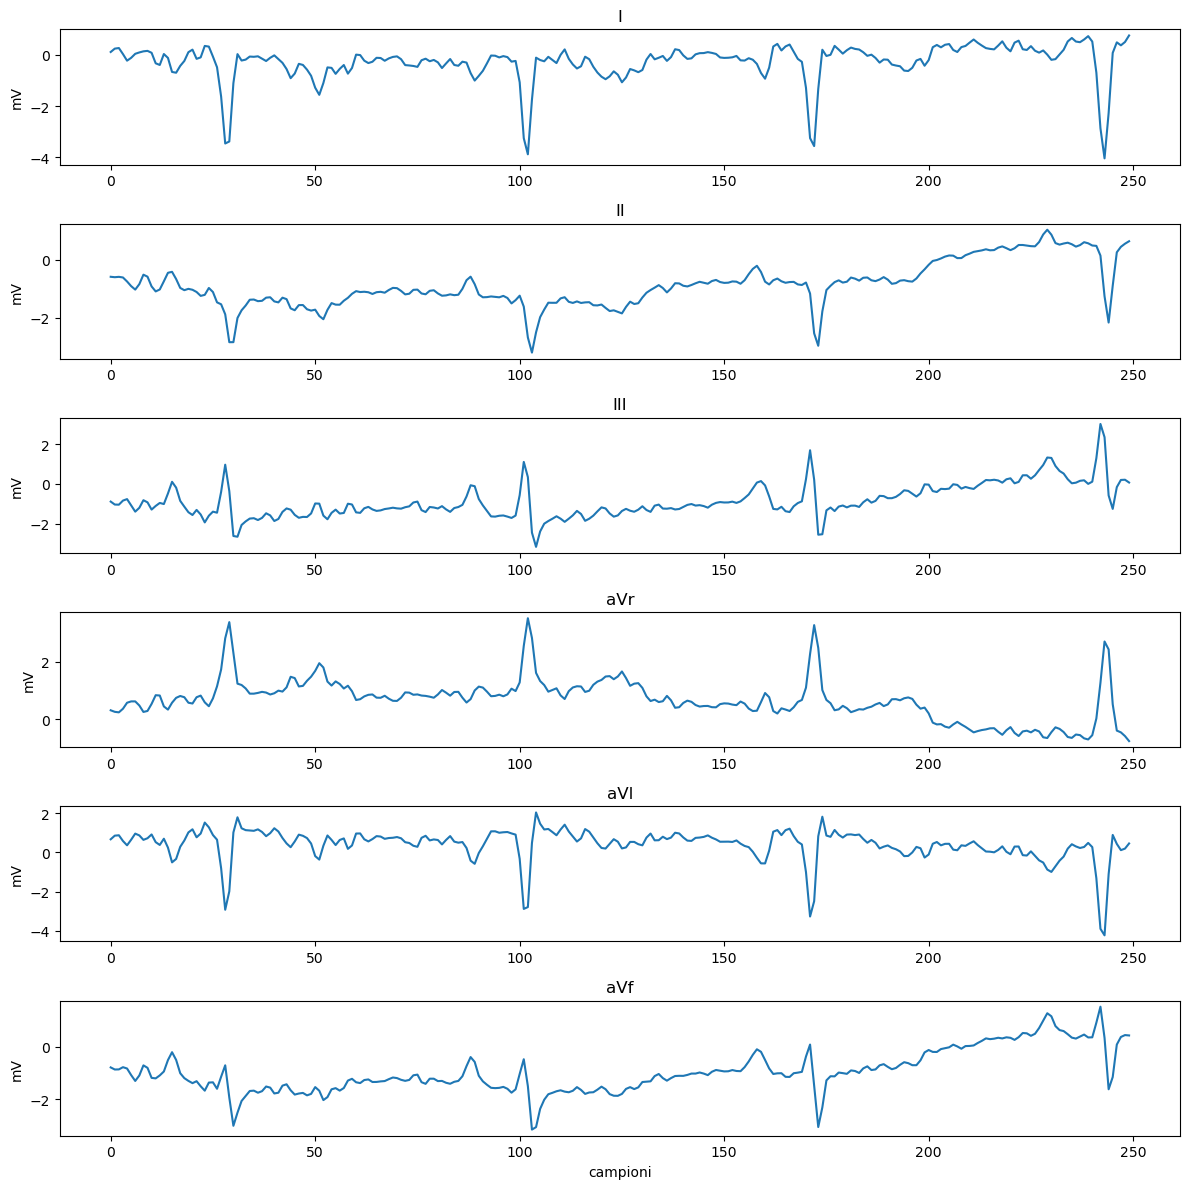


🔹 Finestra 1 — Label: 2


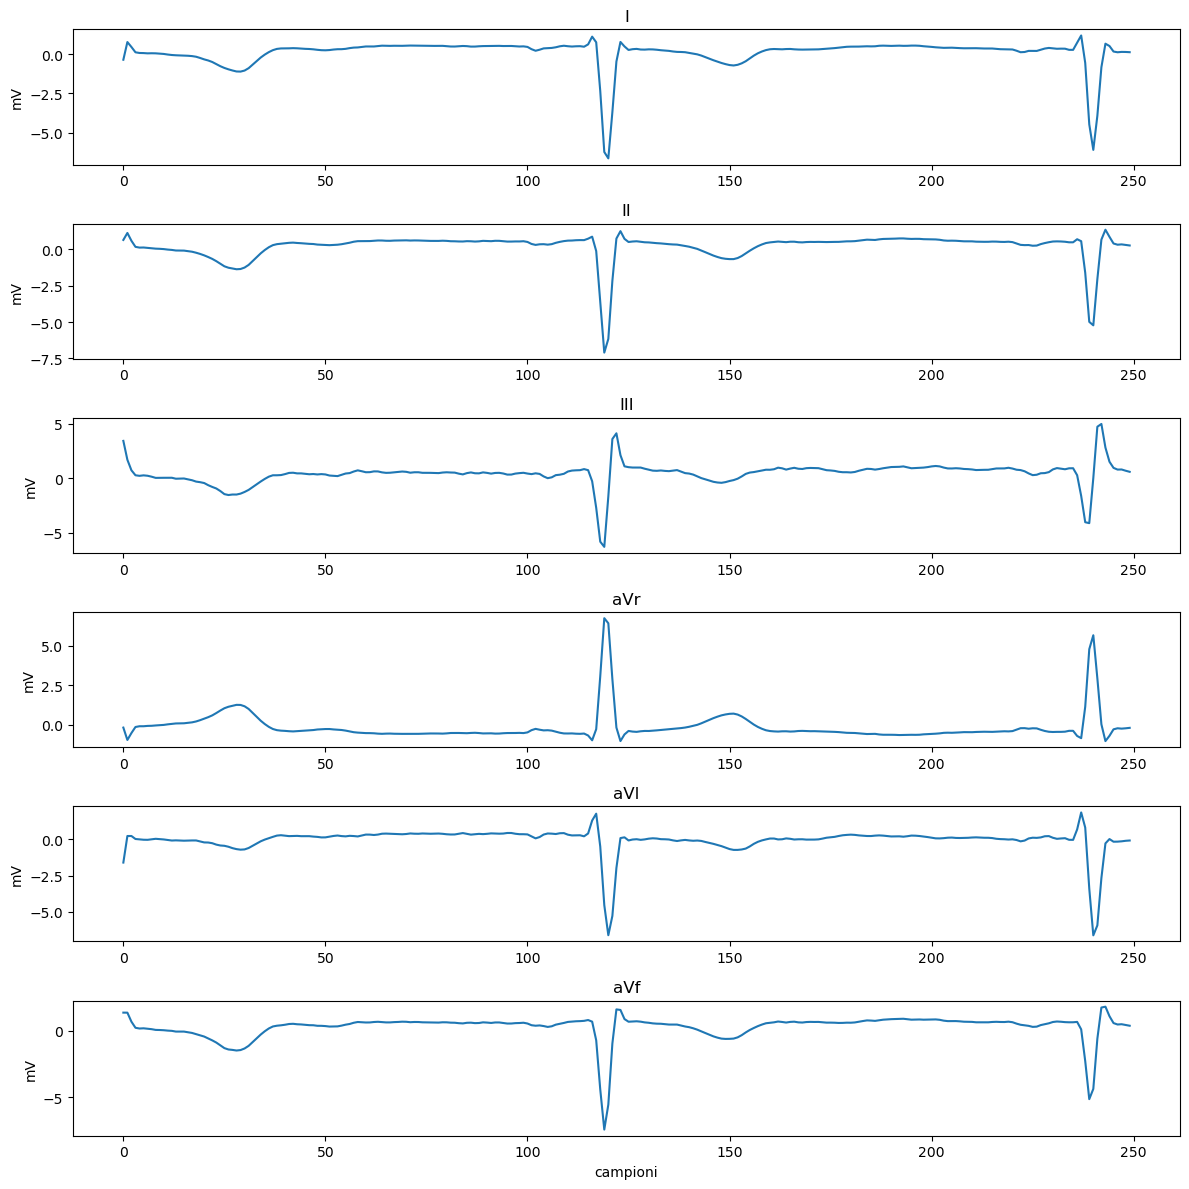


🔹 Finestra 2 — Label: 5


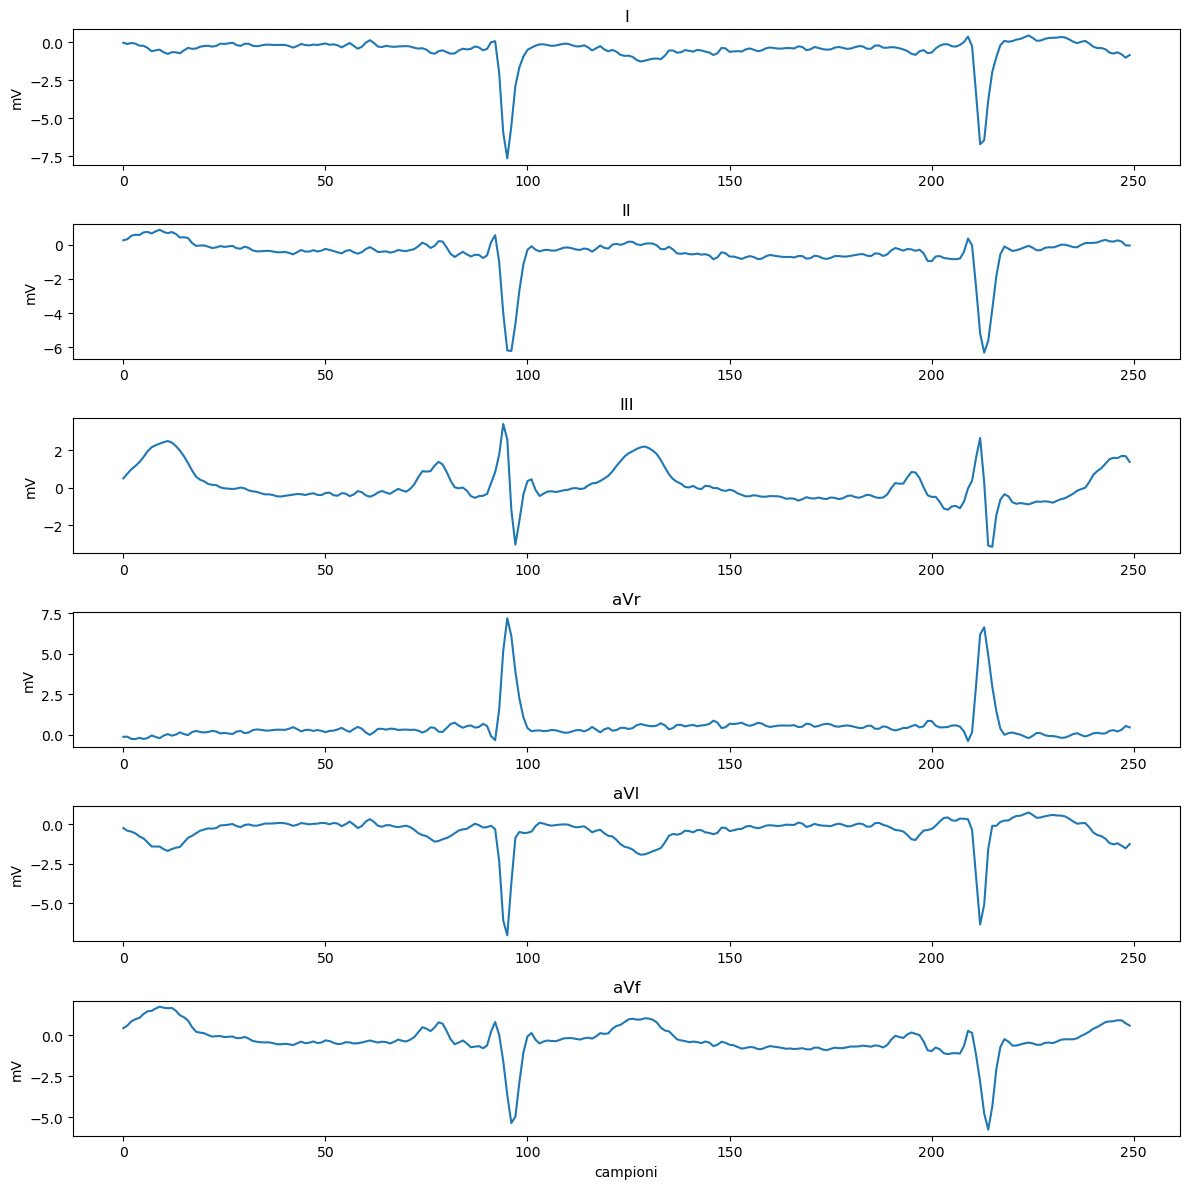


🔹 Finestra 3 — Label: 6


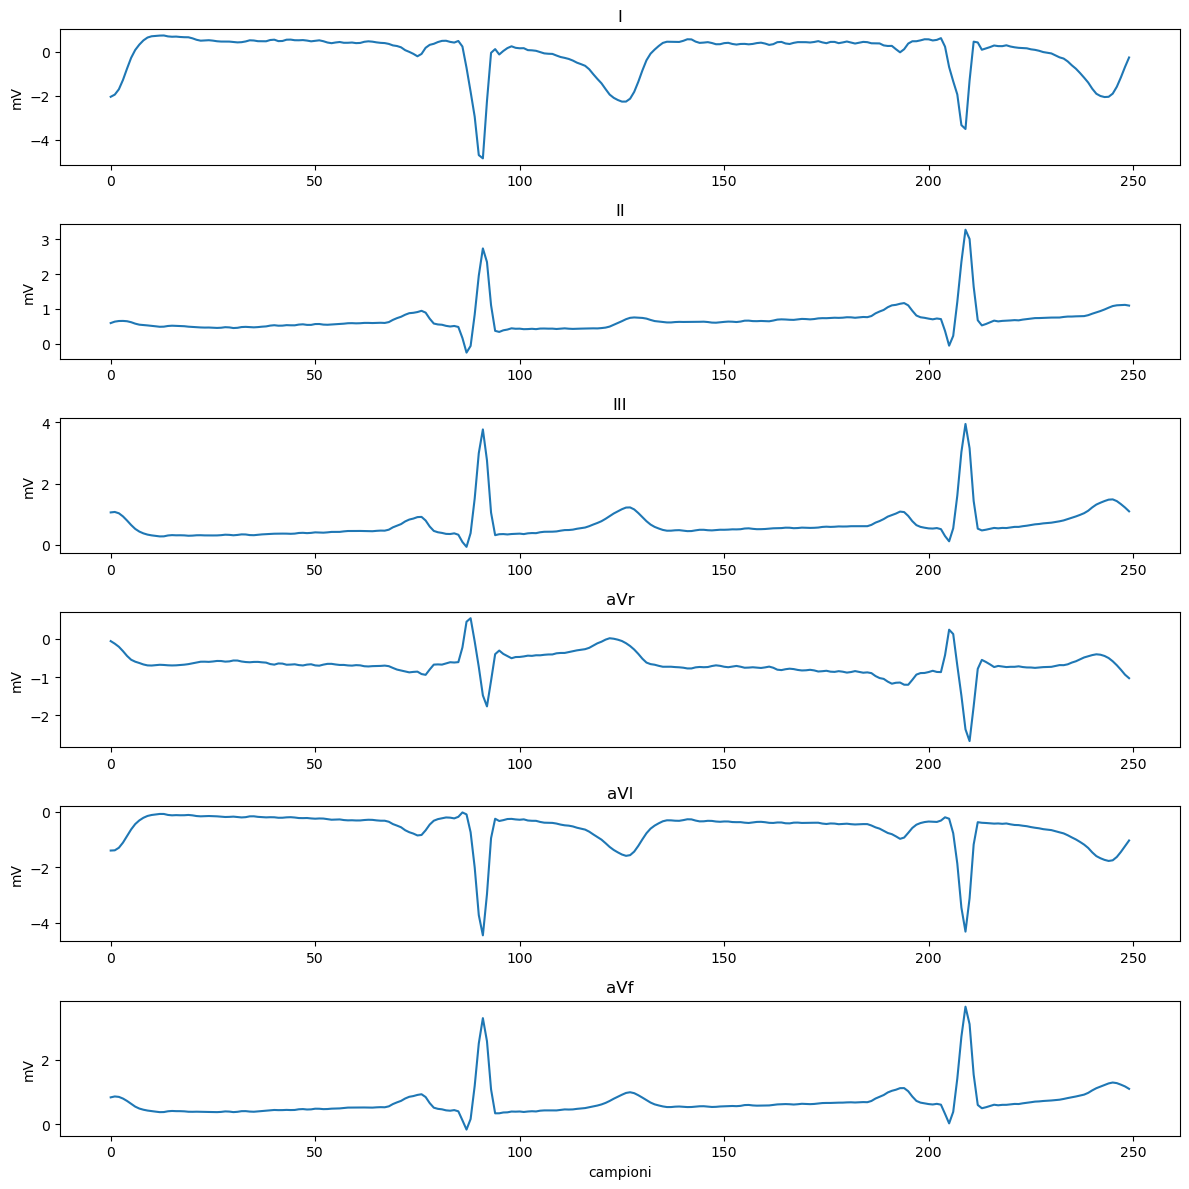


🔹 Finestra 4 — Label: 3


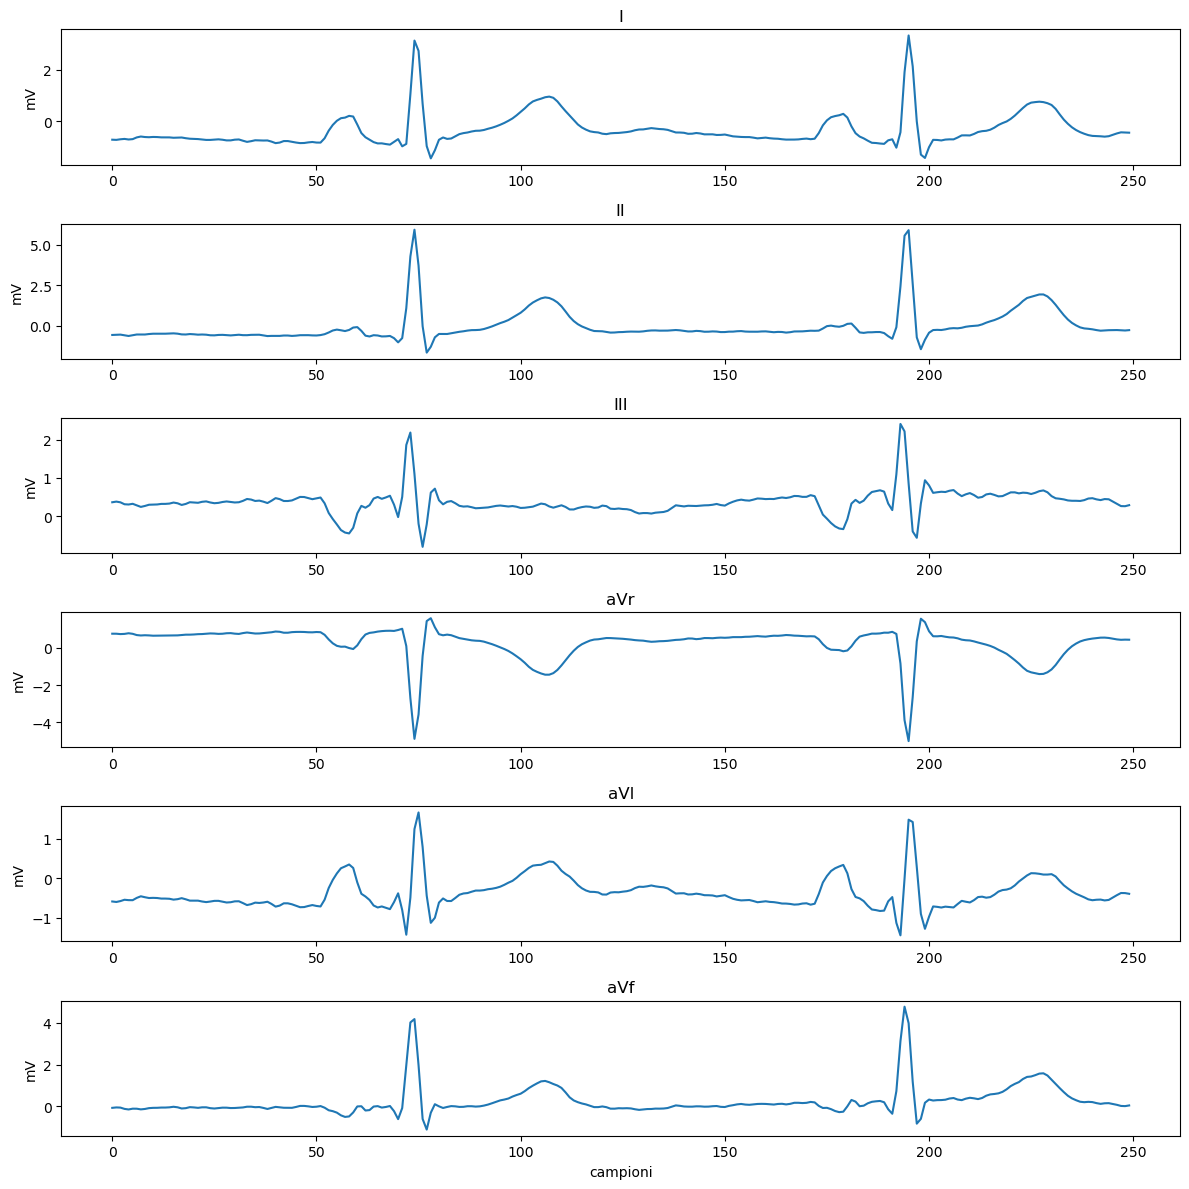


--- Visualizzazione 1 campione con label 'nan' (se esiste) ---
Nessuna finestra con label 'nan' trovata.


In [16]:
import h5py
import numpy as np

def inspect_h5_dataset(filename, n_samples=5):
    print(f"--- Ispezione file: {filename} ---")

    with h5py.File(filename, 'r') as f:
        keys = list(f.keys())
        print(f"Dataset trovati: {keys}")

        if 'X' in f and 'Y' in f:
            X = f['X']
            Y = f['Y']

            print(f"Forma totale X (Segnali): {X.shape}")  # (N_finestre, 12, 250)
            print(f"Forma totale Y (Etichette): {Y.shape}")

            print(f"\n--- Visualizzazione primi {n_samples} campioni ---")
            for i in range(min(n_samples, X.shape[0])):
                label = Y[i]
                sample = X[i]  # shape: (12, 250)

                print(f"\n🔹 Finestra {i} — Label: {label}")
                plot_window_sample(sample)  # funzione già definita
                
            # --- un campione con label 'nan' ---
            print("\n--- Visualizzazione 1 campione con label 'nan' (se esiste) ---")
            labels_str = np.array([lab for lab in Y[:]])
            nan_indices = np.where(labels_str == 'nan')[0]
    
            if len(nan_indices) > 0:
                idx = nan_indices[0]
                label_nan = labels_str[idx]
                sample_nan = X[idx]
                print(f"\n⚠️ Finestra {idx} — Label: {label_nan}")
                plot_window_sample(sample_nan)
            else:
                print("Nessuna finestra con label 'nan' trovata.")

        else:
            print("Errore: Dataset X o Y non trovati nel file!")

            
def plot_window_sample(window, all_leads=ALL_LEADS):
    """
    window: np.array shape (12, 250)
    all_leads: lista di nomi dei lead in ordine
    """
    n_leads = window.shape[0]//2
    plt.figure(figsize=(12, 2 * n_leads))

    for i, lead in enumerate(all_leads[:n_leads], start=1):
        plt.subplot(n_leads, 1, i)
        plt.plot(window[i-1])  # indice numerico
        plt.title(lead)
        plt.ylabel('mV')

    plt.xlabel('campioni')
    plt.tight_layout()
    plt.show()

    
inspect_h5_dataset("train_dataset.h5")

In [17]:
import h5py
import numpy as np
from collections import Counter

def check_class_distribution(filename):
    print(f"--- Distribuzione Classi in {filename} ---")
    
    with h5py.File(filename, 'r') as f:
        if 'Y' in f:
            # Carichiamo tutte le etichette (le etichette sono piccole, la RAM non esploderà)
            labels_bytes = f['Y'][:]
            
            # Decodifichiamo da byte a stringa e contiamo
            labels_str = [l for l in labels_bytes]
            counts = Counter(labels_str)
            
            # Formattiamo l'output per renderlo simile a Pandas
            total = len(labels_str)
            print(f"{'Classe':<20} | {'Conteggio':<10} | {'Percentuale':<10}")
            print("-" * 45)
            
            # Ordiniamo per conteggio decrescente
            for label, count in counts.most_common():
                percent = (count / total) * 100
                print(f"{label:<20} | {count:<10} | {percent:>10.2f}%")
            
            print("-" * 45)
            print(f"{'TOTALE FINESTRE':<20} | {total:<10}")
        else:
            print("Errore: Dataset 'Y' non trovato!")

# Controlliamo entrambi i file
check_class_distribution("test_dataset.h5")
print("\n")
check_class_distribution("train_dataset.h5")

--- Distribuzione Classi in test_dataset.h5 ---
Classe               | Conteggio  | Percentuale
---------------------------------------------
2                    | 841        |      12.50%
0                    | 841        |      12.50%
7                    | 841        |      12.50%
4                    | 841        |      12.50%
5                    | 841        |      12.50%
1                    | 841        |      12.50%
3                    | 841        |      12.50%
6                    | 841        |      12.50%
---------------------------------------------
TOTALE FINESTRE      | 6728      


--- Distribuzione Classi in train_dataset.h5 ---
Classe               | Conteggio  | Percentuale
---------------------------------------------
6                    | 3770       |      12.67%
2                    | 3712       |      12.48%
5                    | 3712       |      12.48%
3                    | 3712       |      12.48%
1                    | 3712       |      12.48%
4        